# 금천구 은행·우체국 후보 구축

분석 설계서 10.2절의 민간시설 활용 검토에 쓸 자료를 만든다. 냉방이 상시 가동되고 주민이 그냥 들어갈 수 있는 시설로 은행과 우체국을 본다.

산출물은 `2_데이터/가공/`에 저장한다.

| 파일 | 내용 |
|---|---|
| `금천구_은행.csv` | 금천구 은행·우체국 통합 목록. 무더위쉼터 지정 여부 포함 |
| `_osm_cache.json` | Overpass, Nominatim 응답 캐시 |

## 자료를 두 곳에서 가져오는 이유

처음에는 소상공인시장진흥공단 상가(상권)정보로 은행을 뽑으려 했으나 이 자료에는 금융업이 들어 있지 않다. 업종 대분류가 음식, 소매, 과학·기술, 보건의료 등 열 개로 한정되어 있고 금융·보험업은 수집 대상이 아니다. 아래 2절에서 이를 직접 확인한다.

그래서 은행 위치는 OpenStreetMap에서 받고, 무더위쉼터 원자료의 금융기관 11곳을 합친다. 두 자료는 성격이 다르다. OSM은 지정 여부와 무관한 지점 전체이고, 쉼터 자료는 이미 무더위쉼터로 지정된 금융기관만 담고 있다. 합쳐야 "금천구에 은행이 어디 있고, 그중 어디가 이미 쉼터인가"를 볼 수 있다.

OSM은 등록 누락이 있을 수 있다. 실제 지점 수보다 적게 잡히면 민간시설 검토 단계에서 현장 확인으로 보완한다.

## 1. 설정

In [1]:
import json
import math
import re
import time
from pathlib import Path

import pandas as pd
import requests

# 이 노트북은 금천구/분석 폴더에서 실행한다고 가정한다.
ROOT = Path.cwd().parents[1]          # 저장소 최상위
RAW = ROOT / "2_데이터" / "원본"        # 서울 전체 원자료
PROC = Path.cwd().parent / "데이터"     # 금천구 산출물
SANGGA = RAW / "소상공인시장진흥공단_상가(상권)정보_서울_202606.csv"
CACHE = PROC / "_osm_cache.json"

SIDO, GU = "서울특별시", "금천구"
UA = {"User-Agent": "geumcheon-shelter-study/0.1"}


## 2. 상가정보에 은행이 있는지 확인

서울 전체 파일이 크므로 20만 행씩 끊어 읽으며 금천구만 모은다. 확인용이므로 파일로 저장하지 않는다.


In [2]:

chunks = []
for ch in pd.read_csv(SANGGA, dtype=str, chunksize=200_000, encoding="utf-8-sig",
                      usecols=["시군구명", "상호명", "상권업종대분류명", "상권업종중분류명",
                               "상권업종소분류명", "표준산업분류명"]):
    chunks.append(ch[ch["시군구명"] == GU])
sangga = pd.concat(chunks, ignore_index=True)

print("금천구 상가업소:", len(sangga), "개")
sangga["상권업종대분류명"].value_counts()


금천구 상가업소: 18353 개


상권업종대분류명
과학·기술      6176
음식         3707
소매         3264
수리·개인      1494
시설관리·임대    1066
교육          841
부동산         739
예술·스포츠      565
보건의료        360
숙박          141
Name: count, dtype: int64

In [3]:
# 업종으로 한 번, 상호명으로 한 번 찾아본다.
by_type = (sangga["표준산업분류명"].fillna("").str.contains("은행|금융")
           | sangga["상권업종소분류명"].fillna("").str.contains("은행|금융"))
by_name = sangga["상호명"].fillna("").str.contains("은행|새마을금고|신협|농협|수협")

print("금융 업종으로 분류된 업소:", by_type.sum(), "개")
print("상호명에 금융 단어가 있는 업소:", by_name.sum(), "개")
sangga.loc[by_name, ["상호명", "상권업종중분류명", "상권업종소분류명"]].head(8)

금융 업종으로 분류된 업소: 0 개
상호명에 금융 단어가 있는 업소: 51 개


,상호명,상권업종중분류명,상권업종소분류명
61,씨제이올리브영은행나무,기타 상품 소매,그 외 기타 상품 전문 소매업
84,피크니크시흥은행나무점,비알코올,카페
269,은행반찬,식료품 소매,반찬/식료품 소매업
553,펀비어킹금천시흥은행나무,주점,생맥주 전문
609,은행피씨,유원지·오락,PC방
971,더치앤빈은행나무,비알코올,카페
1006,굿맘원조할매순대국은행나무,한식,국/탕/찌개류
1851,은행나무종합동물병원,수의,동물병원


상호명에 걸린 업소는 모두 은행나무사거리 상권의 카페, 편의점, 약국이다. 은행 지점은 한 곳도 없다. 상가정보로는 은행을 만들 수 없다.

## 3. OSM에서 은행·우체국 수집

Overpass API로 금천구 경계(admin_level=6) 안의 `amenity=bank`, `office=financial`, `amenity=post_office`를 받는다. 응답은 `_osm_cache.json`에 저장하므로 다시 실행해도 재요청하지 않는다.

In [4]:
_cache = json.loads(CACHE.read_text(encoding="utf-8")) if CACHE.exists() else {}


def _save_cache():
    CACHE.write_text(json.dumps(_cache, ensure_ascii=False), encoding="utf-8")


def overpass(query):
    key = "overpass|" + re.sub(r"\s+", " ", query).strip()
    if key not in _cache:
        r = requests.post("https://overpass-api.de/api/interpreter",
                          data={"data": query}, headers=UA, timeout=180)
        r.raise_for_status()
        _cache[key] = r.json()
        _save_cache()
        time.sleep(1)
    return _cache[key]


def nominatim_reverse(lat, lon):
    """좌표 -> 도로명주소, 법정동. 실패하면 (None, None)."""
    key = f"reverse|{lat:.6f}|{lon:.6f}"
    if key not in _cache:
        r = requests.get("https://nominatim.openstreetmap.org/reverse",
                         params={"lat": lat, "lon": lon, "format": "json",
                                 "accept-language": "ko", "zoom": 18},
                         headers=UA, timeout=30)
        r.raise_for_status()
        _cache[key] = r.json()
        _save_cache()
        time.sleep(1.1)   # Nominatim 이용 규칙: 초당 1회 이하
    return _cache[key]

In [5]:
QUERY = '''[out:json][timeout:120];
area["name"="금천구"]["admin_level"="6"]->.a;
(
  nwr["amenity"="bank"](area.a);
  nwr["office"="financial"](area.a);
  nwr["amenity"="post_office"](area.a);
);
out center tags;'''

elements = overpass(QUERY)["elements"]
print("OSM 요소:", len(elements), "개")

BRANDS = ["KB국민", "국민", "신한", "우리", "하나", "NH농협", "농협", "수협", "기업",
          "SC제일", "씨티", "새마을금고", "신협", "저축은행", "우체국", "산업", "카카오뱅크"]


def brand_of(name):
    for b in BRANDS:
        if b in str(name):
            return "KB국민" if b == "국민" else ("NH농협" if b == "농협" else b)
    return ""


rows = []
for e in elements:
    t = e.get("tags", {})
    lat = e.get("lat") or e.get("center", {}).get("lat")
    lon = e.get("lon") or e.get("center", {}).get("lon")
    if lat is None or lon is None:
        continue
    kind = "우체국" if t.get("amenity") == "post_office" else "은행"
    street, hn = t.get("addr:street"), t.get("addr:housenumber")
    rows.append({
        "구분": kind,
        "시설명": t.get("name", "").strip(),
        "브랜드": brand_of(t.get("name", "")),
        "도로명주소": f"{SIDO} {GU} {street} {hn}" if street and hn else "",
        "운영시간": t.get("opening_hours", ""),
        "위도": float(lat), "경도": float(lon),
        "출처": f"OSM({e['type']}/{e['id']})",
    })

osm = pd.DataFrame(rows)
print(osm["구분"].value_counts().to_string())
osm.head()

OSM 요소: 16 개
구분
은행     12
우체국     4


,구분,시설명,브랜드,도로명주소,운영시간,위도,경도,출처
0,은행,관악농협,NH농협,,,37.450736,126.910208,OSM(node/368638823)
1,은행,영등포농협,NH농협,,,37.478594,126.890138,OSM(node/368638989)
2,우체국,시흥1동우체국,우체국,,,37.458228,126.905133,OSM(node/368875619)
3,우체국,서울가산디지털우체국,우체국,,,37.478060,126.880428,OSM(node/368875743)
4,우체국,서울시흥3우편취급국,,,,37.440979,126.903079,OSM(node/368876274)


주소 태그가 없는 지점은 좌표로 역지오코딩하여 도로명주소를 채운다. 법정동은 모든 지점에 대해 역지오코딩 결과에서 가져온다. OSM 주소 태그에는 동 정보가 없기 때문이다.

In [6]:
DONGS = ("가산동", "독산동", "시흥동")


def dong_of(js):
    for k in ("quarter", "neighbourhood", "suburb", "city_district", "borough"):
        v = str(js.get("address", {}).get(k, ""))
        for d in DONGS:
            if v.startswith(d[:2]):
                return d
    for d in DONGS:
        if d[:2] in str(js.get("display_name", "")):
            return d
    return ""


def road_from(js):
    a = js.get("address", {})
    road, hn = a.get("road"), a.get("house_number")
    return f"{SIDO} {GU} {road} {hn}" if road and hn else ""


dongs, filled = [], 0
for _, r in osm.iterrows():
    js = nominatim_reverse(r["위도"], r["경도"])
    dongs.append(dong_of(js))
    if not r["도로명주소"]:
        addr = road_from(js)
        if addr:
            osm.loc[_, "도로명주소"] = addr
            filled += 1

osm.insert(3, "법정동", dongs)
print("Nominatim으로 채운 주소:", filled, "건")
print("주소 없음:", (osm["도로명주소"] == "").sum(), "건 / 법정동 없음:", (osm["법정동"] == "").sum(), "건")
osm[["구분", "시설명", "법정동", "도로명주소"]].head(20)

Nominatim으로 채운 주소: 3 건
주소 없음: 5 건 / 법정동 없음: 0 건


,구분,시설명,법정동,도로명주소
0,은행,관악농협,시흥동,
1,은행,영등포농협,가산동,
2,우체국,시흥1동우체국,시흥동,
3,우체국,서울가산디지털우체국,가산동,서울특별시 금천구 가산디지털2로 108
4,우체국,서울시흥3우편취급국,시흥동,서울특별시 금천구 시흥대로 77
5,은행,신한은행,가산동,서울특별시 금천구 가산디지털1로 186
6,은행,우리은행,가산동,
7,은행,MG새마을금고,시흥동,서울특별시 금천구 금하로 750
8,은행,KB국민은행,시흥동,서울특별시 금천구 시흥대로 202
9,은행,하나은행,시흥동,서울특별시 금천구 시흥대로 210


Nominatim이 건물번호를 주지 못한 지점은 ArcGIS 역지오코딩으로 한 번 더 시도한다. 좌표에 가장 가까운 주소 지점을 돌려주므로 건물 안의 다른 상호가 함께 오는데, 주소 부분만 쓴다.

In [7]:
def arcgis_reverse(lat, lon):
    """좌표 -> '도로명 건물번호'. 실패하면 빈 문자열."""
    key = f"arcgis_reverse|{lat:.6f}|{lon:.6f}"
    if key not in _cache:
        r = requests.get("https://geocode.arcgis.com/arcgis/rest/services/World/GeocodeServer/reverseGeocode",
                         params={"location": f"{lon},{lat}", "f": "json", "langCode": "ko", "outSR": 4326},
                         headers=UA, timeout=30)
        r.raise_for_status()
        _cache[key] = r.json()
        _save_cache()
        time.sleep(0.3)
    return _cache[key].get("address", {}).get("Address", "")


filled2 = 0
for idx, r in osm.iterrows():
    if r["도로명주소"]:
        continue
    addr = arcgis_reverse(r["위도"], r["경도"])
    if addr:
        osm.loc[idx, "도로명주소"] = f"{SIDO} {GU} {addr}"
        filled2 += 1

print("ArcGIS 역지오코딩으로 채운 주소:", filled2, "건")
print("주소 없음:", (osm["도로명주소"] == "").sum(), "건")
osm[["구분", "시설명", "법정동", "도로명주소"]]

ArcGIS 역지오코딩으로 채운 주소: 5 건
주소 없음: 0 건


,구분,시설명,법정동,도로명주소
0,은행,관악농협,시흥동,서울특별시 금천구 탑골로 2
1,은행,영등포농협,가산동,서울특별시 금천구 가산로 151
2,우체국,시흥1동우체국,시흥동,서울특별시 금천구 독산로 123
3,우체국,서울가산디지털우체국,가산동,서울특별시 금천구 가산디지털2로 108
4,우체국,서울시흥3우편취급국,시흥동,서울특별시 금천구 시흥대로 77
5,은행,신한은행,가산동,서울특별시 금천구 가산디지털1로 186
6,은행,우리은행,가산동,서울특별시 금천구 가산디지털1로 212
7,은행,MG새마을금고,시흥동,서울특별시 금천구 금하로 750
8,은행,KB국민은행,시흥동,서울특별시 금천구 시흥대로 202
9,은행,하나은행,시흥동,서울특별시 금천구 시흥대로 210


## 4. 무더위쉼터로 지정된 금융기관

서울시 무더위쉼터 원자료에서 금천구 금융기관 행을 가져온다. 이 시설들은 이미 쉼터이므로 신규 후보가 아니라 기존 시설이다.

In [8]:
sh_all = pd.read_csv(RAW / "서울시_무더위쉼터.csv", encoding="cp949", dtype=str)
sh = sh_all[sh_all["도로명주소"].fillna("").str.contains(GU)
            | sh_all["지번주소"].fillna("").str.contains(GU)].copy()
fin = sh[sh["시설구분2"].fillna("").str.contains("금융")].copy()

fin_rows = []
for _, r in fin.iterrows():
    fin_rows.append({
        "구분": "은행",
        "시설명": r["쉼터명칭"].strip(),
        "브랜드": brand_of(r["쉼터명칭"]),
        "법정동": next((d for d in DONGS if d in str(r["도로명주소"]) + str(r["지번주소"])), ""),
        "도로명주소": re.sub(r"\(.*?\)", "", str(r["도로명주소"])).strip(),
        "운영시간": f"{r['기본운영_요일']} {r['기본운영_시작시간']}~{r['기본운영_종료시간']}",
        "위도": float(r["위도"]), "경도": float(r["경도"]),
        "출처": "서울시 무더위쉼터",
    })
shelter_fin = pd.DataFrame(fin_rows)
print("쉼터로 지정된 금융기관:", len(shelter_fin), "개소")
shelter_fin[["시설명", "브랜드", "법정동", "도로명주소", "운영시간"]]

쉼터로 지정된 금융기관: 11 개소


,시설명,브랜드,법정동,도로명주소,운영시간
0,새마을금고독산동,새마을금고,독산동,서울특별시 금천구 독산로 323,"월,화,수,목,금 09:00~16:00"
1,국민은행금천지점,KB국민,시흥동,서울특별시 금천구 시흥대로 202,"월,화,수,목,금 09:00~16:00"
2,농협시흥동지점,NH농협,시흥동,서울특별시 금천구 시흥대로 215,"월,화,수,목,금 09:00~16:00"
3,우리은행금천구청지점,우리,시흥동,서울특별시 금천구 시흥대로73길 70,"월,화,수,목,금 09:00~16:00"
4,신한은행시흥점,신한,시흥동,서울특별시 금천구 시흥대로 230,"월,화,수,목,금 09:00~16:00"
5,새마을금고금천남부시흥3동지점,새마을금고,시흥동,서울특별시 금천구 시흥대로 78,"월,화,수,목,금 09:00~16:00"
6,새마을금고시흥제1지점,새마을금고,시흥동,서울특별시 금천구 독산로 140-1,"월,화,수,목,금 09:00~16:00"
7,새마을금고금천남부,새마을금고,시흥동,서울특별시 금천구 금하로 724-1,"월,화,수,목,금 09:00~16:00"
8,신한은행디지털중앙지점,신한,가산동,서울특별시 금천구 가산디지털1로 186,"월,화,수,목,금 09:00~16:00"
9,새마을금고금천중앙,새마을금고,독산동,서울특별시 금천구 가산로 52,"월,화,수,목,금 09:00~16:00"


## 5. 두 자료 합치기

같은 지점이 양쪽에 들어 있을 수 있다. 브랜드가 같고 80m 안에 있으면 같은 지점으로 본다. 은행은 한 건물에 한 곳이고 같은 브랜드의 다른 지점이 80m 안에 붙어 있는 경우는 드물다. 주소 문자열은 OSM과 쉼터 자료의 표기가 달라 대조 기준으로 쓰지 않는다.

합칠 때 쉼터 자료를 기준으로 삼고, OSM 지점은 짝이 없을 때만 새 행으로 넣는다. 짝이 맞으면 `무더위쉼터지정`을 Y로 적는다.

In [9]:
def meters(lat1, lon1, lat2, lon2):
    """두 좌표 사이 거리(m). 하버사인."""
    R = 6371000.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = p2 - p1
    dl = math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


NEAR_M = 80

merged = shelter_fin.copy()
merged["무더위쉼터지정"] = "Y"
merged["쉼터명칭"] = merged["시설명"]
merged["OSM확인"] = ""

added = []
for _, o in osm.iterrows():
    hit = None
    for i, s in merged.iterrows():
        if o["브랜드"] and o["브랜드"] == s["브랜드"] and \
                meters(o["위도"], o["경도"], s["위도"], s["경도"]) <= NEAR_M:
            hit = i
            break
    if hit is not None:
        merged.loc[hit, "OSM확인"] = o["출처"]
        if not merged.loc[hit, "운영시간"].strip() and o["운영시간"]:
            merged.loc[hit, "운영시간"] = o["운영시간"]
    else:
        rec = o.to_dict()
        rec.update({"무더위쉼터지정": "N", "쉼터명칭": "", "OSM확인": o["출처"]})
        added.append(rec)

banks = pd.concat([merged, pd.DataFrame(added)], ignore_index=True)
banks = banks[["구분", "시설명", "브랜드", "법정동", "도로명주소", "운영시간",
               "무더위쉼터지정", "쉼터명칭", "위도", "경도", "출처", "OSM확인"]]
banks[["위도", "경도"]] = banks[["위도", "경도"]].round(7)
banks = banks.sort_values(["구분", "법정동", "브랜드", "시설명"]).reset_index(drop=True)

print("쉼터 자료", len(shelter_fin), "+ OSM", len(osm), "->", len(banks), "행")
print("양쪽 모두에 있는 지점:", (merged["OSM확인"] != "").sum(), "곳")
pd.crosstab(banks["구분"], banks["무더위쉼터지정"])

쉼터 자료 11 + OSM 16 -> 24 행
양쪽 모두에 있는 지점: 3 곳


무더위쉼터지정,N,Y
구분,,
우체국,4,0
은행,9,11


In [10]:
banks.to_csv(PROC / "금천구_은행.csv", index=False, encoding="utf-8-sig")
print("저장:", (PROC / "금천구_은행.csv").resolve())

print()
print("[법정동별]")
print(pd.crosstab(banks["법정동"], banks["구분"]))
print()
print("[브랜드별]")
print(banks["브랜드"].value_counts().to_string())
banks[banks["무더위쉼터지정"] == "N"][["구분", "시설명", "법정동", "도로명주소", "운영시간"]]

저장: C:\Users\USER\OneDrive\바탕 화면\공모전\shelter-location-mclp\금천구\데이터\금천구_은행.csv

[법정동별]
구분   우체국  은행
법정동         
가산동    1   3
독산동    0   4
시흥동    3  13

[브랜드별]
브랜드
새마을금고    7
NH농협     4
우체국      3
신한       3
우리       3
         1
KB국민     1
신협       1
하나       1


,구분,시설명,법정동,도로명주소,운영시간
0,우체국,서울가산디지털우체국,가산동,서울특별시 금천구 가산디지털2로 108,
1,우체국,서울시흥3우편취급국,시흥동,서울특별시 금천구 시흥대로 77,
2,우체국,서울시흥동우체국,시흥동,서울특별시 금천구 시흥대로 217,
3,우체국,시흥1동우체국,시흥동,서울특별시 금천구 독산로 123,
4,은행,영등포농협,가산동,서울특별시 금천구 가산로 151,
6,은행,우리은행,가산동,서울특별시 금천구 가산디지털1로 212,
7,은행,NH농협은행,독산동,서울특별시 금천구 시흥대로 336,
12,은행,관악농협,시흥동,서울특별시 금천구 탑골로 2,
14,은행,MG새마을금고,시흥동,서울특별시 금천구 금하로 750,09:00-16:00
18,은행,신한은행,시흥동,서울특별시 금천구 시흥대로 97,Mo-Fr 09:00-18:00


## 6. 확인용 지도

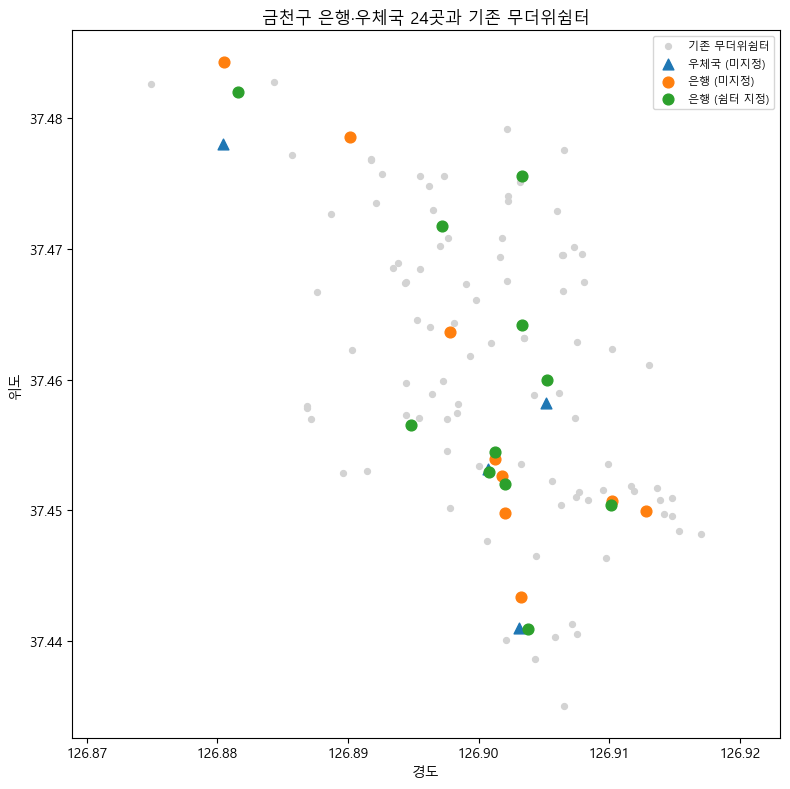

In [11]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

shelters = pd.read_csv(PROC / "금천구_무더위쉼터.csv")

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(shelters["경도"], shelters["위도"], s=18, c="lightgray", label="기존 무더위쉼터")
for (kind, designated), g in banks.groupby(["구분", "무더위쉼터지정"]):
    label = f"{kind} ({'쉼터 지정' if designated == 'Y' else '미지정'})"
    ax.scatter(g["경도"], g["위도"], s=60, marker="^" if kind == "우체국" else "o", label=label)

ax.set_title(f"금천구 은행·우체국 {len(banks)}곳과 기존 무더위쉼터")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.legend(fontsize=8)
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()


## 다음 단계

여기서 만든 목록 중 은행은 `facilities_geumcheon.ipynb`에서 후보시설에 합쳐진다. 금천구는 이미 은행 11곳을 무더위쉼터로 운영하고 있어 후보로서의 현실성이 확인된 시설 유형이다.

우체국 4곳은 후보에 넣지 않고 목록에만 둔다. 넣으려면 facilities 노트북의 은행 절에서 `구분` 필터를 바꾸면 된다.

검토 시 확인할 사항은 두 가지다. 은행은 평일 9시부터 16시까지만 열어 폭염 피크 시간대의 뒷부분이 비고, 주말에는 닫는다. 그리고 OSM 등록 누락이 있으므로 사각지대에 남는 지점은 현장에서 확인한다.
